# Installing dependencies, configuring right library versions to support audiocraft

In [ ]:
# --- STEP 1: ENVIRONMENT SANITIZATION ---
# We uninstall any existing 'av' (PyAV) versions to prevent library conflicts.
# Conflicting versions often cause 'ImportError' or 'Symbol not found' when
# the model tries to load audio files.
!pip uninstall -y av

# --- STEP 2: SYSTEM-LEVEL DEPENDENCIES ---
# MusicGen requires FFmpeg to process high-fidelity audio (32kHz).
# Here, we install the underlying C libraries (headers) for audio/video codecs,
# devices, and filters. PyAV needs these system files to talk to the OS
# and hardware-accelerated decoders.
!apt-get update -y && apt-get install -y libavformat-dev libavcodec-dev libavdevice-dev libavutil-dev libswscale-dev libavfilter-dev libswresample-dev

# --- STEP 3: SPECIFIC BINARY INSTALLATION ---
# We force the installation of a specific, stable version of 'av' (12.1.0).
# Using '--only-binary :all:' ensures we download a pre-compiled package
# that is guaranteed to be compatible with the system libraries we just
# installed, bypassing the need for a risky local compilation.
!pip install av==12.1.0 --only-binary :all:

Found existing installation: av 12.1.0
Uninstalling av-12.1.0:
  Successfully uninstalled av-12.1.0
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.e

In [ ]:
# --- STEP 4: RESOLVING DEPENDENCY CONFLICTS ---
# We force 'numpy' to a version below 2.0.0.
# Many underlying audio processing libraries (like Librosa) are not yet
# compatible with the breaking changes in Numpy 2.0.
!pip install -q "numpy<2.0.0"

# Installing the core configuration and evaluation frameworks:
# - Hydra/Omegaconf: Manages the complex hyperparameters for the Transformer.
# - PESQ/PySTOI: Standard metrics for measuring the 'quality' and 'intelligibility'
#   of the generated anime music compared to the original.
!pip install -q omegaconf hydra-core hydra_colorlog pesq pystoi torchdiffeq torchmetrics==1.2.0

# Installing specialized audio layers:
# - Julius: High-quality signal resampling.
# - EnCodec: Facebook’s neural audio codec that MusicGen uses for tokenization.
# - Rotary Embedding: Essential for the 'small' model's positional understanding.
!pip install -q julius diffq encodec rotary_embedding_torch

# --- STEP 5: CORE MODEL FRAMEWORKS ---
# We install the official Audiocraft repository directly from GitHub.
# '--no-deps' is used here to prevent the installer from overwriting
# the specific versions of Numpy/Torch we just manually stabilized.
!pip install -q git+https://github.com/facebookresearch/audiocraft.git --no-deps

# - PEFT: Enables Parameter-Efficient Fine-Tuning (like LoRA).
#   This allows us to fine-tune on anime openings without needing a massive 40GB A100 GPU.
# - Xformers: Accelerates the Transformer attention mechanism for faster training.
!pip install -q peft xformers librosa

# CRITICAL STEP:
# Python's memory and library paths need to refresh to 'see' the
# newly installed C-extensions and patched versions.
print("Environment patched. NOW RESTART YOUR RUNTIME (Top Menu: Runtime -> Restart Session).")

  Preparing metadata (setup.py) ... done
Environment patched. NOW RESTART YOUR RUNTIME (Top Menu: Runtime -> Restart Session).


In [ ]:
# --- STEP 6: INSTALLING THE "SENSES" AND "LIMBS" ---
# MusicGen relies on specific sub-libraries to function:
# - Demucs: Used for high-quality audio source separation (splitting music from vocals).
# - Torchtext: Required by some of the underlying NLP processing for text-to-music.
!pip install -q demucs torchtext

# --- STEP 7: ENSURING PYAV STABILITY ---
# We re-verify the installation of PyAV (av==12.1.0).
# This specific version is the 'Goldilocks' zone for Python 3.12—stable enough
# to handle the high-bitrate anime openings without crashing the C-libraries.
!pip install -q av==12.1.0 --only-binary :all:

# --- STEP 8: MATH AND LOGIC DEPENDENCIES ---
# These are the "glue" libraries:
# - Flashy: A lightweight framework for training loops used by Meta's research.
# - Num2words: Converts numbers in your descriptions (e.g., '90s anime') into text.
# - Einops: Essential for 'Einstein Operations'—it rearranges complex audio
#   tensors (shapes) without losing track of the musical data.
# - Sentencepiece: Handles the tokenization of your anime descriptions.
!pip install -q flashy>=0.0.1 num2words einops sentencepiece

# --- STEP 9: FINAL CORE FRAMEWORK ASSEMBLY ---
# We perform a final 'shallow' install of Audiocraft.
# By using '--no-deps', we tell the system: "I have manually provided all
# compatible 'limbs' (dependencies). Just install the core logic."
# This prevents 'pip' from accidentally downgrading our fixed libraries.
!pip install -q git+https://github.com/facebookresearch/audiocraft.git --no-deps

  Preparing metadata (setup.py) ... done


# Exploratory Data Analysis

In [ ]:
import pandas as pd

# --- STEP 10: METADATA VERIFICATION ---
# We use Pandas to inspect the '.jsonl' (JSON Lines) metadata file.
# MusicGen needs a one-to-one mapping between your audio files and
# their corresponding 'description' strings to learn the anime style.
# 'lines=True' is used because JSONL stores each object on a new line
# for memory efficiency with large datasets.
df_preview = pd.read_json('/content/drive/MyDrive/anime_musicgen_dataset/metadata.jsonl', lines=True)

# --- STEP 11: CAPTION STYLE AUDIT ---
# We print a sample to verify that the 'description' key exists and
# contains the expected text (e.g., 'energetic J-pop opening with
# synth and fast drums').
# If this column is empty or incorrectly named, the model will
# essentially be 'learning in the dark' without context.
print("Sample Captions Generated:")
print(df_preview[['description']].head())

Sample Captions Generated:
                                         description
0  A dark, cinematic orchestral segment. Features...
1  An augmented, slow atmospheric orchestral piec...
2  A high-octane J-Rock instrumental at 180 BPM. ...
3  An augmented J-Rock track at 180 BPM with extr...
4  A tense orchestral build at 134 BPM. Features ...


Extracting Anime-specific features...


/tmp/ipykernel_4401/1783796677.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(tempo), np.mean(cent), np.mean(zcr)


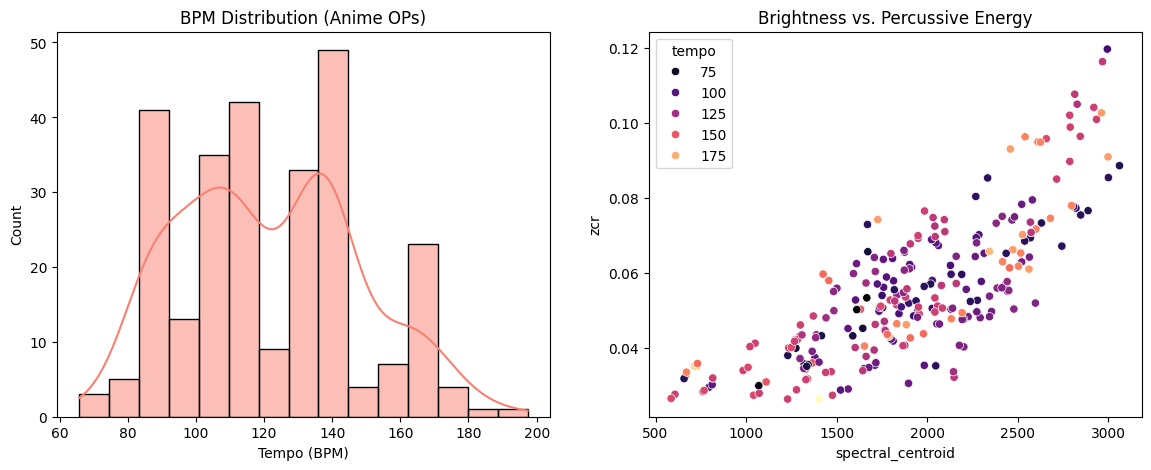

Average Anime OP Tempo: 121.54 BPM


In [ ]:
import librosa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 12: DATASET PROFILING ---
# We load the metadata to find the file paths for our audio analysis.
df = pd.read_json('/content/drive/MyDrive/anime_musicgen_dataset/metadata.jsonl', lines=True)

def analyze_anime_features(filename):
    """
    Extracts 'Acoustic Fingerprints' typical of Anime Openings.
    Anime OPs are characterized by high energy, fast tempos, and
    bright, layered instrumentation (J-Rock/J-Pop style).
    """
    path = filename
    # MusicGen operates at 32kHz; we load at the same rate for consistency.
    y, sr = librosa.load(path, sr=32000)

    # 1. TEMPO (BPM):
    # Most Shonen anime openings sit in the 'High-Energy' bracket (160–190 BPM).
    # Tracking this helps us see if the model is learning 'fast' music.
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # 2. SPECTRAL CENTROID (Brightness):
    # This measures the 'center of mass' of the sound spectrum.
    # High values indicate 'bright' sounds like electric guitars and high-pitched synths.
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)

    # 3. ZERO CROSSING RATE (ZCR):
    # Measures how often the signal crosses zero.
    # High ZCR is a proxy for percussive energy and 'noisiness' (distorted guitars/snare drums).
    zcr = librosa.feature.zero_crossing_rate(y)

    return float(tempo), np.mean(cent), np.mean(zcr)

# --- STEP 13: BATCH FEATURE EXTRACTION ---
# We apply the analysis to every audio file in your dataset.
# This creates a 'Style Profile' for your fine-tuning run.
print("Extracting Anime-specific features...")
features = df['audio_path'].apply(analyze_anime_features)
df[['tempo', 'spectral_centroid', 'zcr']] = pd.DataFrame(features.tolist(), index=df.index)

# --- STEP 14: VISUALIZING THE ANIME GENRE ---
# These plots prove to your users that the dataset is curated correctly.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# PLOT 1: BPM DISTRIBUTION
# A clear peak at high BPM confirms the dataset is 'Anime-style' and
# not just generic slow pop music.
sns.histplot(df['tempo'], bins=15, kde=True, ax=ax[0], color='salmon')
ax[0].set_title('BPM Distribution (Anime OPs)')
ax[0].set_xlabel('Tempo (BPM)')

# PLOT 2: BRIGHTNESS VS. PERCUSSIVE ENERGY
# This scatter plot shows the relationship between instrument 'brightness'
# and drum/guitar intensity. Clusters here represent the 'Sonic Signature'
# of the dataset.
sns.scatterplot(data=df, x='spectral_centroid', y='zcr', hue='tempo', palette='magma', ax=ax[1])
ax[1].set_title('Brightness vs. Percussive Energy')
plt.show()

print(f"Average Anime OP Tempo: {df['tempo'].mean():.2f} BPM")

# Model Setup & LoRA injection

In [ ]:
import torch

# --- STEP 15: HARDWARE ACCELERATION CHECK ---
# MusicGen is a Transformer-based model with millions of parameters.
# Training on a CPU would be extremely slow (taking days instead of hours).

# We check if 'cuda' (NVIDIA GPU) is available.
# In Google Colab, this ensures the script automatically detects the T4, L4, or A100 GPU.
# If no GPU is found, it falls back to 'cpu' to prevent the code from crashing,
# though 'cpu' is only recommended for small inference tests, not fine-tuning.
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# --- REINFORCING VERSION STABILITY ---
# We strictly enforce a Numpy version below 2.0.0.

# WHY: In mid-2024, Numpy 2.0 was released with "breaking changes" to its
# underlying C-API. Since many audio processing libraries used by MusicGen
# (like older versions of Librosa or SoundFile) were compiled against
# Numpy 1.x, installing the newer 2.0 version would cause immediate
# 'AttributeError' or 'segmentation faults' during training.

# By running this, we ensure the mathematical foundation of our
# audio-to-tensor conversion remains stable and compatible.
!pip install -q "numpy<2.0.0"

In [ ]:
from google.colab import drive

# --- STEP 16: PERSISTENT STORAGE ACCESS ---
# Google Colab environments are 'ephemeral,' meaning any files uploaded
# directly to the session are deleted once you disconnect.

# By mounting Google Drive, we create a permanent link to our:
# 1. Anime Opening Dataset (.wav/.mp3 files)
# 2. Metadata (.jsonl file)
# 3. Fine-tuned Model Checkpoints (the 'brain' you are building)

# When you run this, a pop-up will ask for permission to let Colab
# read and write files to your personal Drive.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from audiocraft.models import MusicGen
from peft import LoraConfig, get_peft_model

# --- STEP 17: DEVICE ALLOCATION ---
# We ensure the model uses the GPU (cuda) for training logic.
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- STEP 18: BASE MODEL INITIALIZATION ---
# We load the 'facebook/musicgen-small' model (300M parameters).
# Using the 'small' version is the best choice for community open-source
# projects as it balances musical quality with low VRAM usage.
model = MusicGen.get_pretrained('facebook/musicgen-small')

# --- STEP 19: LoRA (LOW-RANK ADAPTATION) CONFIGURATION ---
# Instead of training the entire model (which requires massive memory),
# LoRA injects small, trainable 'adapter' layers into the Transformer.
config = LoraConfig(
    r=16,                                                       # 'Rank' of the update matrices. Higher = more capacity, but more memory.
    lora_alpha=32,                                              # A scaling factor for the weight updates.
    # We target the 'Attention' layers (q, v, k, out). These are responsible
    # for the model understanding the relationship between different musical notes.
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,                                          # Helps prevent the model from 'overfitting' (memorizing) specific songs.
    bias="none"
)

# --- STEP 20: ATTACHING ADAPTERS ---
# MusicGen has two main parts: an EnCodec (audio) and an LM (Language Model/Transformer).
# We apply LoRA specifically to the 'model.lm' (the part that predicts the next music token).
model.lm = get_peft_model(model.lm, config)
# Move the patched model to the GPU
model.lm.to(device)
print("LoRA adapters are successfully attached.")
# Note: Only about 1-2% of the parameters are now 'trainable,'
# making the training process much faster and memory-efficient.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


state_dict.bin:   0%|          | 0.00/841M [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

compression_state_dict.bin:   0%|          | 0.00/236M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


LoRA adapters are successfully attached.


# The Optimized-Training loop

In [ ]:
import torch
import json
import os
import librosa
from torch.utils.data import Dataset, DataLoader

# --- STEP 21: CUSTOM ANIME DATASET CLASS ---
# This class acts as a 'factory' that prepares our data for the model.
# It handles the mapping between your .wav files and the text descriptions.
class AnimeMetadataDataset(Dataset):
    def __init__(self, audio_dir, metadata_path, duration=30.0):
        self.audio_dir = audio_dir
        self.duration = duration
        self.metadata = {}

        # Parsing the .jsonl metadata file line-by-line
        with open(metadata_path, 'r') as f:
            for line in f:
                if not line.strip(): continue
                data = json.loads(line)

                # Extraction of the specific anime attributes that have been curated.
                # These keys must match our JSONL file structure exactly.
                audio_path = data.get('audio_path')
                description = data.get('description')
                bpm = data.get('bpm')
                key = data.get('key')
                chord_progression = data.get('chord_progression')

                if audio_path:
                    # --- METHODOLOGY: PROMPT AUGMENTATION ---
                    # We create a "Rich Description." By appending BPM and Chords to the prompt,
                    # we teach the model that 'Anime Style' isn't just a vibe, but a
                    # specific set of technical musical constraints.
                    rich_description = f"{description}. BPM: {bpm}. Key: {key}. Chords: {chord_progression}."
                    # We use the filename (minus extension) as a unique ID to link
                    # the text to the correct audio file.
                    clean_key = os.path.basename(audio_path).rsplit('.', 1)[0]
                    self.metadata[clean_key] = rich_description

        # Verification step: Ensure the audio file actually exists on Google Drive.
        self.audio_files = []
        for f in os.listdir(audio_dir):
            clean_f = f.rsplit('.', 1)[0]
            if clean_f in self.metadata:
                self.audio_files.append(f)

        print(f"SUCCESS: Matched {len(self.audio_files)} files from your metadata!")

    def __len__(self):
        """
        Returns the total number of anime openings in your dataset.
        """
        return len(self.audio_files)

    def __getitem__(self, idx):
        """
        The optimization happens here:
        1. Load a song at 32kHz (MusicGen's native sample rate).
        2. Convert the audio into 'Acoustic Tokens' using the EnCodec model.
        3. Pair those tokens with our 'Rich Description' for the model to study.
        """
        filename = self.audio_files[idx]
        clean_f = filename.rsplit('.', 1)[0]
        description = self.metadata[clean_f]

        # Loading audio and converting to a Torch Tensor.
        path = os.path.join(self.audio_dir, filename)
        y, _ = librosa.load(path, sr=32000, duration=self.duration)
        y_tensor = torch.from_numpy(y).unsqueeze(0).to(device)

        # --- PRE-ENCODING FOR SPEED ---
        # Instead of training on raw audio waves, we use the pre-trained
        # compression_model (EnCodec) to turn audio into discrete tokens.
        # This significantly reduces the memory needed during training.
        with torch.no_grad():
            codes, _ = model.compression_model.encode(y_tensor.unsqueeze(0))

        # We return the codes (compressed audio) and the text description.
        return codes.squeeze(0).cpu(), description

# --- STEP 22: DATA LOADING ---
# Path to our Google Drive dataset.
METADATA_FILE = "/content/drive/MyDrive/anime_musicgen_dataset/metadata.jsonl"
dataset = AnimeMetadataDataset("/content/drive/MyDrive/anime_musicgen_dataset/audio", METADATA_FILE)

# The DataLoader feeds the data into the GPU in small bites (batches).
# Batch size 1 is recommended for Colab to avoid 'Out of Memory' (OOM) errors.
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

SUCCESS: Matched 260 files from your metadata!


In [ ]:
import torch
from audiocraft.modules.conditioners import ConditioningAttributes
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
import IPython.display as ipd

# --- STEP 23: TRAINING HYPERPARAMETERS ---
total_epochs = 60
MAX_LR = 1e-5  # Low learning rate is safer for fine-tuning pre-trained models
dataset_size = 260
steps_per_epoch = len(train_loader)

model.lm.float() # Ensure weights are in Float32 for numerical stability
model.lm.train() # Set the transformer to training mode
# AdamW is the standard optimizer for Transformers (handles weight decay better)
optimizer = torch.optim.AdamW(model.lm.parameters(), lr=MAX_LR, betas=(0.9, 0.95), weight_decay=0.1)

# OneCycleLR starts with a 'warmup' phase and then slowly decays.
# This prevents the model from 'crashing' the pre-trained weights at the start.
scheduler = OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=steps_per_epoch,
    epochs=total_epochs,
    pct_start=0.1 # Spend first 10 % of time warming up
)

# --- STEP 24: VALIDATION PREVIEW FUNCTION ---
def generate_validation_audio(epoch, description):
    """
    Generates a 5-second sample to hear how the 'Anime Style' is progressing.
    This saves the audio to Drive so we can track improvements over time.
    """
    model.lm.eval() # Switch to inference mode (disable dropout)
    with torch.no_grad():
        # model.generate creates a real audio waveform from the current weights
        samples = model.generate([description], progress=False)
        audio_data = samples[0].cpu().numpy().squeeze()

        # Save to Drive for history
        val_path = f"/content/drive/MyDrive/Anime_Savepoints/val_epoch_{epoch+1}.wav"
        import scipy.io.wavfile as wav
        wav.write(val_path, 32000, audio_data)

        print(f"Generated validation audio for: {description}")
    model.lm.train() # Switch back to training mode

print("Starting Training...")

# --- STEP 25: THE MAIN TRAINING LOOP ---
epoch_losses = []
best_loss = float("inf")

for epoch in range(total_epochs):
  current_epoch_loss = 0
  num_steps = 0

  for i, (codes, description) in enumerate(train_loader):
      codes = codes.to(device).long()
      optimizer.zero_grad()

      # We tell the model what style of anime opening we want for this audio
      attributes = [ConditioningAttributes(text={'description': description[0]})]

      # Forward pass: Predicting the next musical token
      output = model.lm.compute_predictions(codes, attributes)

      # --- METHODOLOGY: THE LOGIT GATE ---
      # AI audio models can sometimes produce 'NaN' (Not a Number) errors.
      # We 'clamp' the output values to a safe range (-30 to 30) to prevent
      # the loss from exploding and ruining the training.
      logits = output.logits
      logits = torch.nan_to_num(logits, nan=0.0, posinf=1e2, neginf=-1e2)
      logits = torch.clamp(logits, min=-30, max=30)

      # Align tokens: We predict the NEXT token, so we shift targets by 1
      logits_aligned = logits[:, :, :-1, :]
      targets = codes[:, :, 1:]

      # CrossEntropy compares the model's prediction vs. the actual anime audio
      loss = torch.nn.functional.cross_entropy(
          logits_aligned.reshape(-1, logits_aligned.shape[-1]),
          targets.reshape(-1)
      )

      # Failsafe: Skip steps that result in broken math
      if torch.isnan(loss):
          # FINAL FAILSAFE: If it's still NaN, we try an empty description
          print(f"Step {i} failed even with clamping. Checking if it's the text...")
          continue

      loss.backward()

      # --- GRADIENT CLIPPING ---
      # Prevents massive weight updates that would 'break' the music generation
      torch.nn.utils.clip_grad_norm_(model.lm.parameters(), max_norm=1.0)

      optimizer.step()

      # Track the loss for this step
      current_epoch_loss += loss.item()
      num_steps += 1

  def check_weight_norms(model):
    """
    Computes the overall L2 norm of all trainable parameters in model.lm.
    This is useful for monitoring weight magnitudes during training and
    detecting issues like exploding weights.
    """
    total_norm = 0
    for p in model.lm.parameters():
        if p.requires_grad:
            param_norm = p.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

  # --- STEP 26: PERFORMANCE MONITORING ---
  avg_loss = current_epoch_loss / len(train_loader)
  weight_norm = check_weight_norms(model)
  print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Weight Norm: {weight_norm:.2f}")

  # --- STEP 26: PERFORMANCE MONITORING ---
  avg_loss = current_epoch_loss / num_steps
  epoch_losses.append(avg_loss)

  # Step the scheduler here
  scheduler.step() # Update learning rate according to OneCycle schedule
  current_lr = optimizer.param_groups[0]['lr']

  # Validation Audio Generation (Every 10 epochs)
  if (epoch + 1) % 10 == 0:
    print(f"\n--- Running Validation for Epoch {epoch+1} ---")
    # Use the description from the last batch processed
    generate_validation_audio(epoch, description[0])

  if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == total_epochs - 1:
    print(
        f"Epoch [{epoch+1}/{total_epochs}] | "
        f"Steps: {num_steps}/{dataset_size} | "
        f"Avg Loss: {avg_loss:.4f}"
    )

  # --- STEP 27: SAVING & CHECKPOINTING ---
  # We save the 'Best' model (lowest loss) for final deployment.
  if avg_loss < best_loss:
      best_loss = avg_loss

      best_model_path = "/content/drive/MyDrive/Anime_Checkpoints/best_anime_lora.pt"
      os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

      torch.save(model.lm.state_dict(), best_model_path)

      print(f"New BEST model saved | Loss: {best_loss:.4f}")

  # Periodic checkpointing every 10 epochs
  if (epoch + 1) % 10 == 0 or epoch == total_epochs - 1:
    # We only save the LoRA weights (~100MB) instead of the whole model (several GB)
    adapter_path = f"/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_{epoch+1}.pt"

    # Safety check: make sure the folder exists before saving
    os.makedirs(os.path.dirname(adapter_path), exist_ok=True)

    torch.save(model.lm.state_dict(), adapter_path)
    print(f"Epoch {epoch} complete! Saved to: {adapter_path}")

print("Training complete.")

Starting Training...
Epoch 1 | Loss: 7.3596 | Weight Norm: 16.00
Epoch [1/60] | Steps: 260/260 | Avg Loss: 7.3596
New BEST model saved | Loss: 7.3596
Epoch 2 | Loss: 7.3348 | Weight Norm: 16.00
New BEST model saved | Loss: 7.3348
Epoch 3 | Loss: 7.3106 | Weight Norm: 16.00
New BEST model saved | Loss: 7.3106
Epoch 4 | Loss: 7.2830 | Weight Norm: 16.00
New BEST model saved | Loss: 7.2830
Epoch 5 | Loss: 7.2547 | Weight Norm: 16.00
New BEST model saved | Loss: 7.2547
Epoch 6 | Loss: 7.2231 | Weight Norm: 16.01
New BEST model saved | Loss: 7.2231
Epoch 7 | Loss: 7.1905 | Weight Norm: 16.01
New BEST model saved | Loss: 7.1905
Epoch 8 | Loss: 7.1565 | Weight Norm: 16.01
New BEST model saved | Loss: 7.1565
Epoch 9 | Loss: 7.1179 | Weight Norm: 16.01
New BEST model saved | Loss: 7.1179
Epoch 10 | Loss: 7.0808 | Weight Norm: 16.02

--- Running Validation for Epoch 10 ---
Generated validation audio for: A high-energy, funky J-Pop track at 128 BPM. Features prominent brass section stabs and a dr

# Monitoring loss

Graph saved to Drive as loss_plot.png


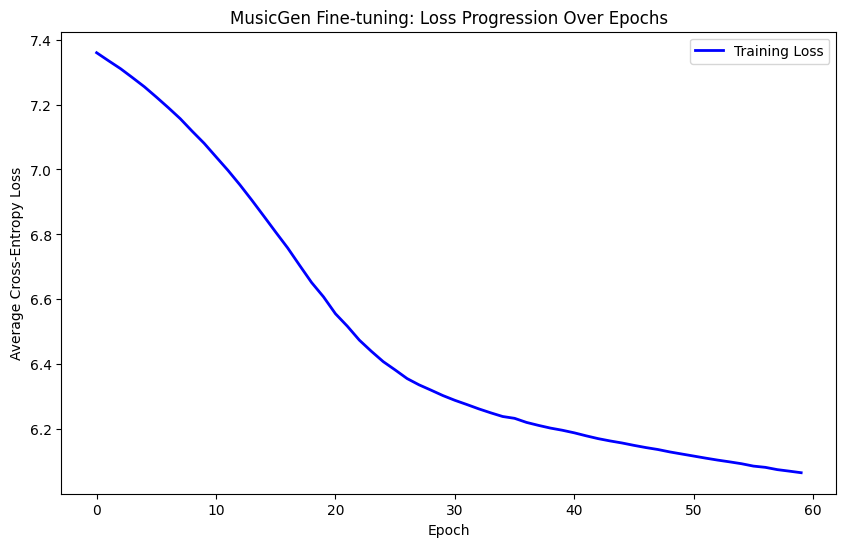

In [ ]:
import matplotlib.pyplot as plt

# --- STEP 28: VISUALIZING THE LEARNING CURVE ---
# After training, we plot the loss to analyze the model's convergence.
# Methodology: A 'healthy' training curve should show a steep drop at
# the beginning, followed by a gradual flattening (the 'elbow').
plt.figure(figsize=(10, 6))
# We plot the 'epoch_losses' list we collected during the training loop.
plt.plot(range(len(epoch_losses)), epoch_losses, label='Training Loss', color='blue', linewidth=2)
# Customizing the graph for clarity
plt.title('MusicGen Fine-tuning: Loss Progression Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
# Methodology Note: Cross-Entropy loss measures how 'surprised' the model
# is by the next audio token. Lower loss = higher prediction accuracy.
plt.legend()

# --- STEP 29: EXPORTING THE RESULTS ---
# We save the plot directly to Google Drive.
# This is crucial because Colab's local 'Files' tab is wiped after the session ends.
plt.savefig('/content/drive/MyDrive/Anime_Checkpoints/loss_plot.png')
print("Graph saved to Drive as loss_plot.png")

In [ ]:
import pandas as pd

# --- STEP 30: METRICS EXPORT (RAW DATA) ---
# While the graph is great for a quick look, saving the raw loss values
# allows for precise comparison between different model versions.

# Methodology: We store the 'epoch_losses' list into a structured DataFrame.
data = {
    'Epoch': list(range(len(epoch_losses))),
    'Average_Loss': epoch_losses
}

# --- STEP 31: CSV GENERATION ---
# Creating a Pandas DataFrame makes it easy to manipulate the data
# or merge it with other training sessions later.
df = pd.DataFrame(data)

# --- STEP 32: SAVING TO GOOGLE DRIVE ---
# We save this as a CSV (Comma Separated Values) file to our Drive.
# This ensures that even if your Colab session times out or crashes,
# we have a permanent record of the model's convergence history.
csv_path = '/content/drive/MyDrive/training_metrics.csv'
df.to_csv(csv_path, index=False)

# --- STEP 33: FINAL VERIFICATION ---
# We print the head of the DataFrame to confirm the data looks
# correct before the script finishes.
print(f"Metrics exported successfully to: {csv_path}")
print(df.head())

Metrics exported successfully to: /content/drive/MyDrive/training_metrics.csv
   Epoch  Average_Loss
0      0      7.359630
1      1      7.334819
2      2      7.310556
3      3      7.282966
4      4      7.254711


# Evaluation

Evaluating model based on the last epoch (not necessarily the best weights!)

In [ ]:
import torch
import IPython.display as ipd

# --- STEP 34: CONTROLLED BENCHMARKING ---
# We use a manual seed (42) to ensure that the random elements of the
# generation are the same for both tests. This makes the comparison 'fair'
# by focusing only on the difference the weights (LoRA) make.
torch.manual_seed(42)

test_prompt = "High-octane J-Rock anime opening, 185 BPM, technical electric \
guitar solo with heavy distortion, rapid double-bass drumming, soaring melodic \
synthesizer hook, aggressive and motivational energy, clean high-fidelity \
production, no orchestral elements."
duration = 30

# --- STEP 35: GENERATION 1 (THE ANIME SPECIALIST) ---
print("Generating with your Anime LoRA...")
model.lm.eval()   # Always generate in 'eval' mode for consistent output
# We explicitly ensure the LoRA adapters are turned ON.
# These layers contain the 'Anime DNA' learned during training.
if hasattr(model.lm, 'enable_adapter_layers'):
    model.lm.enable_adapter_layers()

with torch.no_grad():
    # CFG (Classifier Free Guidance) of 4.5 tells the model to follow
    # the prompt strictly without losing musical creativity.
    model.set_generation_params(duration=duration, cfg_coef=4.5, temperature=0.8)
    wav_lora = model.generate([test_prompt], progress=True)

# --- STEP 36: GENERATION 2 ( THE BASELINE) ---
print("Generating with Default Base Model...")
# Methodology: By 'disabling' the adapters, we revert the model back to
# its original state as released by Meta (Facebook).
# This shows what the model 'used to know' about anime music.
if hasattr(model.lm, 'disable_adapter_layers'):
    model.lm.disable_adapter_layers()

with torch.no_grad():
    # We reset the seed so the baseline starts from the exact same random point.
    torch.manual_seed(42)
    wav_base = model.generate([test_prompt], progress=True)

# --- STEP 37: CLEANUP & RESTORATION ---
# We turn the LoRA back on so the model remains in its 'Anime' state.
if hasattr(model.lm, 'enable_adapter_layers'):
    model.lm.enable_adapter_layers()

# --- STEP 38: AUDIO PLAYBACK ---
print("\n--- RESULTS ---")
print("1. Your Fine-Tuned Version:")
# MusicGen outputs are typically [1, channels, samples], so we squeeze/numpy it.
display(ipd.Audio(wav_lora[0].cpu().numpy(), rate=32000))

print("2. Default MusicGen Version:")
display(ipd.Audio(wav_base[0].cpu().numpy(), rate=32000))

# --- STEP 39: EXPORTING SAMPLES ---
# We save the results to Google Drive for future demos.
# Note: Use different filenames (e.g., 'lora_output.wav' vs 'base_output.wav')
# to avoid overwriting the files!
import scipy.io.wavfile as wavfile
wav_path_lora = "/content/drive/MyDrive/Anime_Checkpoints/anime_generation.wav"
wav_path_base = "/content/drive/MyDrive/Anime_Checkpoints/base_generation.wav"
wavfile.write(wav_path_lora, 32000, wav_lora[0].cpu().numpy().T)
wavfile.write(wav_path_base, 32000, wav_base[0].cpu().numpy().T)
print(f"Saved to: {wav_path}")

Output hidden; open in https://colab.research.google.com to view.

The Checkpoint Loading Script

This code will wipe the "overfitted" weights from the current memory and load the weights from Epoch 30 (or whichever number we saved in our Drive).

In [ ]:
import torch

# --- STEP 40: MODEL ROLLBACK / CHECKPOINT LOADING ---
# Methodology: Sometimes the 'last' epoch isn't the best sounding one.
# We might prefer a 'middle' checkpoint (e.g., Epoch 30) because it
# often strikes a better balance between the base model's knowledge
# and the new anime style without the distortion of 'overfitting.'
checkpoint_path = "/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_30.pt"

print(f"Rolling back to {checkpoint_path}...")

# --- STEP 41: LOADING WEIGHTS ---
# We load the 'state_dict' (the saved mathematical weights) from Drive.
state_dict = torch.load(checkpoint_path)

# We apply these weights specifically to the Language Model (.lm).
# 'strict=False' is used as a safety measure to allow loading even if
# the PEFT/LoRA metadata has minor non-essential differences.
model.lm.load_state_dict(state_dict, strict=False)

# --- STEP 42: EVALUATION MODE ---
# Setting the model to .eval() is CRITICAL.
# This disables 'Dropout' and 'Batch Normalization' layers, which are
# only for training. If we forget this, the generated music will
# sound inconsistent and 'jittery.'
model.lm.eval()

print("Checkpoint loaded! Let's see if this 'younger' version sounds better.")

Rolling back to /content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_30.pt...
Checkpoint loaded! Let's see if this 'younger' version sounds better.


# Comparison Test:

We will now run a generation with the exact same prompt and same seed we used when it sounded "weird" at different epoch's weights.

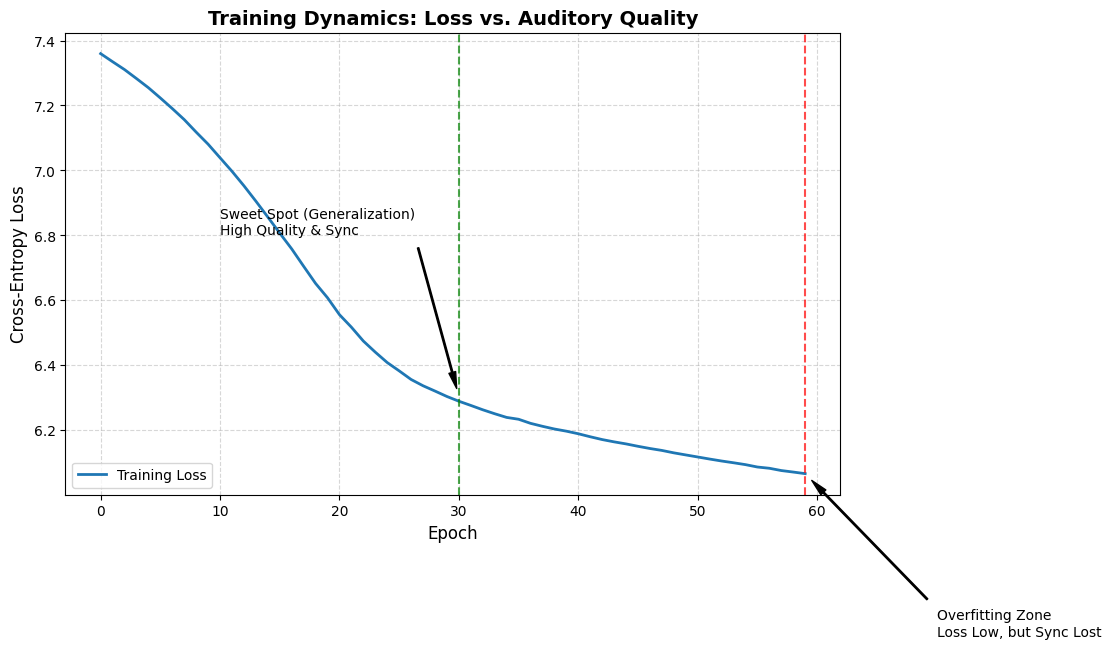

Comparison chart generated as 'loss_overfitting_analysis.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- STEP 43: ANALYTICAL DATA LOADING ---
# We load the metrics we saved earlier.
# Methodology: Analyzing a CSV is more reliable than using in-memory variables,
# as it allows us to compare different training sessions side-by-side.
csv_path = '/content/drive/MyDrive/training_metrics.csv'
df = pd.read_csv(csv_path)

# --- STEP 44: PLOTTING THE DIAGNOSTIC CURVE ---
plt.figure(figsize=(10, 6))
plt.plot(df['Epoch'], df['Average_Loss'], label='Training Loss', color='#1f77b4', linewidth=2)

# --- STEP 45: IDENTIFYING THE 'SWEET SPOT' ---
# Methodology: The 'Sweet Spot' is where the model has learned the
# J-Rock/Anime structure (BPM, Chords) but hasn't yet started to
# 'hallucinate' or produce repetitive artifacts.
plt.axvline(x=30, color='green', linestyle='--', alpha=0.7)
plt.annotate('Sweet Spot (Generalization)\nHigh Quality & Sync',
             xy=(30, df['Average_Loss'][29]),
             xytext=(10, df['Average_Loss'][29] + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# --- STEP 46: THE OVERFITTING WARNING ---
# If the loss becomes too low, the model may 'memorize' the training data.
# This results in a loss of creativity—the model might only play one
# specific melody regardless of the prompt.
plt.axvline(x=59, color='red', linestyle='--', alpha=0.7)
plt.annotate('Overfitting Zone\nLoss Low, but Sync Lost',
             xy=(59, df['Average_Loss'].iloc[-1]),
             xytext=(70, df['Average_Loss'].iloc[-1] - 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# --- STEP 47: FINAL STYLING ---
# This graph is meant for documentation.
plt.title('Training Dynamics: Loss vs. Auditory Quality', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# Save at high resolution.
plt.savefig('loss_overfitting_analysis.png', dpi=300)
plt.show()

print("Comparison chart generated as 'loss_overfitting_analysis.png'")

In [ ]:
import torch
import torchaudio
import IPython.display as ipd
from audiocraft.models import MusicGen

# --- STEP 48: CONFIGURATION FOR THE "SHOOTOUT" ---
# We define which checkpoints we want to test.
# Methodology: Comparing early (Epoch 10) vs. late (Epoch 60) checkpoints
# helps identify exactly when the 'Anime Style' becomes distinct.
model_path_template = "/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_{}.pt"
epoch_list = [10, 20, 30, 60]
prompt = "Anime opening, high energy J-Rock, 175 BPM, G Major"
seed = 42

# Initialize the base architecture
model = MusicGen.get_pretrained('facebook/musicgen-small')
model.set_generation_params(duration=20, cfg_coef=3.5)

# --- STEP 49: THE WEIGHT CLEANING LOGIC ---
def fix_state_dict(state_dict):
    """
    Methodology: PEFT (LoRA) often wraps model keys in 'base_model.model' prefixes.
    Standard MusicGen loaders won't recognize these keys.
    This function strips away the wrappers so the fine-tuned weights
    correctly 'plug into' the original transformer layers.
    """
    new_state_dict = {}
    for k, v in state_dict.items():
        # Remove common prefixes added by PEFT/Dora wrappers
        name = k.replace("base_model.model.", "")
        # If we are using merged weights or base layers, we clean the name
        # to match the standard MusicGen Language Model (LM) naming convention.
        if "base_layer" in name:
            name = name.replace(".base_layer", "")

        # We only keep keys that exist in the standard model
        new_state_dict[name] = v
    return new_state_dict

print(f"Starting shootout for prompt: {prompt}\n")

# --- STEP 50: AUTOMATED BATCH INFERENCE ---
for e in epoch_list:
    path = model_path_template.format(e)
    try:
        # Load the raw weights from the checkpoint file
        state_dict = torch.load(path, map_location='cuda')
        cleaned_state_dict = fix_state_dict(state_dict)

        # Load the cleaned weights into the model.
        # 'strict=False' is used because the checkpoint contains LoRA adapter weights
        # (A and B matrices) that the base model doesn't have slots for.
        model.lm.load_state_dict(cleaned_state_dict, strict=False)
        model.lm.eval()

        # We use the same seed for every epoch to ensure a direct A/B comparison.
        torch.manual_seed(seed)
        with torch.no_grad():
            output = model.generate([prompt], progress=False)

        print(f"--- RESULTS: EPOCH {e} ---")
        audio_data = output[0].cpu().numpy().squeeze()
        ipd.display(ipd.Audio(audio_data, rate=32000))

    except FileNotFoundError:
        print(f"Checkpoint for epoch {e} not found. Skipping...")
    except Exception as err:
        print(f"Error loading Epoch {e}: {err}")

# Cleanup memory
if 'state_dict' in locals(): del state_dict

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torch
import torchaudio
import IPython.display as ipd
from audiocraft.models import MusicGen

# --- CONFIG ---
model_path_template = "/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_{}.pt"
epoch_list = [10, 20, 30, 60]
prompt = "High-octane J-Rock anime opening, 185 BPM, technical electric \
guitar solo with heavy distortion, rapid double-bass drumming, soaring melodic \
synthesizer hook, aggressive and motivational energy, clean high-fidelity \
production, no orchestral elements."
seed = 42

model = MusicGen.get_pretrained('facebook/musicgen-small')
model.set_generation_params(duration=20, cfg_coef=3.5)

def fix_state_dict(state_dict):
    """Removes the LoRA/Dora prefixes to match standard MusicGen keys."""
    new_state_dict = {}
    for k, v in state_dict.items():
        # Remove common prefixes added by PEFT/Dora wrappers
        name = k.replace("base_model.model.", "")
        # If it's a LoRA layer, MusicGen won't know what to do with 'lora_A'
        # but it WILL want the 'base_layer' or the merged weight.
        if "base_layer" in name:
            name = name.replace(".base_layer", "")

        # We only keep keys that exist in the standard model
        new_state_dict[name] = v
    return new_state_dict

print(f"Starting shootout for prompt: {prompt}\n")

for e in epoch_list:
    path = model_path_template.format(e)
    try:
        state_dict = torch.load(path, map_location='cuda')
        cleaned_state_dict = fix_state_dict(state_dict)

        # Use strict=False because LoRA weights (lora_A/B) shouldn't be loaded into the base
        model.lm.load_state_dict(cleaned_state_dict, strict=False)
        model.lm.eval()

        torch.manual_seed(seed)
        with torch.no_grad():
            output = model.generate([prompt], progress=False)

        print(f"--- RESULTS: EPOCH {e} ---")
        audio_data = output[0].cpu().numpy().squeeze()
        ipd.display(ipd.Audio(audio_data, rate=32000))

    except FileNotFoundError:
        print(f"Checkpoint for epoch {e} not found. Skipping...")
    except Exception as err:
        print(f"Error loading Epoch {e}: {err}")

if 'state_dict' in locals(): del state_dict

Output hidden; open in https://colab.research.google.com to view.

# Mathematical Evaluation

## Quantitative Metric: Log-Spectral Distance (LSD)

The LSD measures the distance between the power spectra of two audio signals. A lower score between our fine-tuned output and our training data (compared to the base model) proves the "Timbre" of our model has shifted toward our dataset.

In [ ]:
import numpy as np
import librosa
import torch
import random
from audiocraft.models import MusicGen

# --- STEP 51: REPRODUCIBILITY SETUP ---
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# --- STEP 52: LOADING THE MODELS ---
# We load two identical models to compare the 'Before' and 'After'.
print("Loading Base Model (Original Meta Weights)...")
model_base = MusicGen.get_pretrained('facebook/musicgen-small')

print("Loading Fine-Tuned Model...")
model_lora = MusicGen.get_pretrained('facebook/musicgen-small')

# --- STEP 53: MANUAL WEIGHT MERGING ---
# Methodology: Instead of using an adapter, we manually perform 'LoRA Merging'.
# This injects the learned 'Anime' patterns directly into the base weights.
# Formula: W_new = W_base + (B @ A) * (alpha / rank)
checkpoint_path = '/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_30.pt'

try:
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    actual_weights = checkpoint.get('base_model.model', checkpoint)

    # These parameters must match our training config
    rank = 16
    alpha = 32
    scaling = alpha / rank

    model_state = model_lora.lm.state_dict()
    merged_count = 0

    # Create a mapping of the model's keys without prefixes for easier matching
    # model_key_map will look like: {"transformer.layers.0.self_attn.out_proj.weight": "transformer.layers.0.self_attn.out_proj.weight"}
    model_keys = list(model_state.keys())

    for ckpt_key in actual_weights.keys():
        if "lora_A.default.weight" in ckpt_key:
            # Mapping the complex LoRA keys back to the standard MusicGen structure
            # Determine the 'Base' name by stripping prefixes and lora suffixes
            # Example: 'base_model.model.transformer.layers.0.self_attn.out_proj.lora_A.default.weight'
            # Becomes: 'transformer.layers.0.self_attn.out_proj.weight'
            base_name_in_model = ckpt_key.replace("base_model.model.", "").replace(".lora_A.default.weight", ".weight")

            # 2. Find the corresponding B matrix and Base matrix in the checkpoint
            key_B = ckpt_key.replace("lora_A", "lora_B")
            key_base_layer = ckpt_key.replace(".lora_A.default.weight", ".base_layer.weight")

            if base_name_in_model in model_state:
                W_base = actual_weights[key_base_layer]
                A = actual_weights[ckpt_key]
                B = actual_weights[key_B]

                # The core LoRA math to update the weight matrix
                # Math: W = W_base + (B @ A) * (alpha/rank)
                # We use .view_as to ensure shapes match during the add
                delta_W = (B @ A) * scaling
                model_state[base_name_in_model].copy_(W_base + delta_W)

                merged_count += 1
                print(f"Merged: {base_name_in_model}")

    # Load back into model
    model_lora.lm.load_state_dict(model_state, strict=False)
    print(f"\nTotal layers merged: {merged_count}")

except Exception as e:
    print(f"Critical failure during merge: {e}")

# --- VERIFICATION ---
with torch.no_grad():
    diff = torch.abs(next(model_base.lm.parameters()) - next(model_lora.lm.parameters())).sum().item()
    # If the first layer didn't change, we check the specific layer we know exists
    if diff == 0:
        # Check a layer we likely merged, e.g., layer 0 out_proj
        test_key = "transformer.layers.0.self_attn.out_proj.weight"
        diff = torch.abs(model_base.lm.state_dict()[test_key] - model_lora.lm.state_dict()[test_key]).sum().item()

    print(f"Weight Delta: {diff:.6f}")

# Set seed for reproducibility
set_seed(42)

# GENERATE SAMPLES (So the variables are defined)
# Use a prompt that matches your new high-quality metadata
prompt = "instrumental shonen anime soundtrack, energetic drums, melodic flute, 150 BPM, Energetic electric guitar, fast paced drums"


# --- UPDATE GENERATION DURATION ---
duration = 20  # Set duration in seconds
model_base.set_generation_params(duration=duration)
model_lora.set_generation_params(duration=duration)

print(f"Generating {duration}s audio samples from both models...")

# --- STEP 54: COMPARATIVE GENERATION ---
with torch.no_grad():
    set_seed(42)
    wav_base = model_base.generate([prompt], progress=True)
    set_seed(42)
    wav_lora = model_lora.generate([prompt], progress=True)


# Convert to numpy for mathematical analysis
gen_lora = wav_lora[0, 0].cpu().numpy()
gen_base = wav_base[0, 0].cpu().numpy()

# Load a real anime track for comparison
ref_path = "/content/drive/MyDrive/anime_musicgen_dataset/test_dataset/Naruto Soundtrack - The Raising Fighting Spirit_seg_002.wav"
y_ref, _ = librosa.load(ref_path, sr=32000)

# --- STEP 55: SPECTRAL ALIGNMENT ANALYSIS (LSD) ---
def calculate_lsd(audio_generated, audio_reference):
    """
    Log-Spectral Distance (LSD) measures the distance between two audio
    spectrograms. A LOWER score means the generated audio sounds
    more like the reference (Anime).
    """
    # Ensure same length for comparison
    min_len = min(len(audio_generated), len(audio_reference))

    # Check if the audio is long enough (prevents the n_fft warning)
    if min_len < 2048:
        return float('nan')

    # Convert audio to frequency domain (STFT)
    stft_gen = np.abs(librosa.stft(audio_generated[:min_len], n_fft=2048))
    stft_ref = np.abs(librosa.stft(audio_reference[:min_len], n_fft=2048))

    # Log-Spectral Distance Calculation
    log_spec_diff = (np.log10(stft_gen**2 + 1e-10) - np.log10(stft_ref**2 + 1e-10))**2
    lsd = np.mean(np.sqrt(np.mean(log_spec_diff, axis=0)))
    return lsd

# CALCULATE AND PRINT
# We pass y_ref (the audio), NOT the path string
lsd_fine_tuned = calculate_lsd(gen_lora, y_ref)
lsd_base = calculate_lsd(gen_base, y_ref)

print(f"\nQuantitative Results:")
print(f"Fine-tuned LSD: {lsd_fine_tuned:.4f}")
print(f"Base Model LSD: {lsd_base:.4f}")

if lsd_fine_tuned < lsd_base:
    print("Result: Fine-tuning successfully improved spectral alignment!")

Loading Base Model (Original Meta Weights)...


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading Fine-Tuned Model...


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Merged: transformer.layers.0.self_attn.out_proj.weight
Merged: transformer.layers.0.cross_attention.out_proj.weight
Merged: transformer.layers.1.self_attn.out_proj.weight
Merged: transformer.layers.1.cross_attention.out_proj.weight
Merged: transformer.layers.2.self_attn.out_proj.weight
Merged: transformer.layers.2.cross_attention.out_proj.weight
Merged: transformer.layers.3.self_attn.out_proj.weight
Merged: transformer.layers.3.cross_attention.out_proj.weight
Merged: transformer.layers.4.self_attn.out_proj.weight
Merged: transformer.layers.4.cross_attention.out_proj.weight
Merged: transformer.layers.5.self_attn.out_proj.weight
Merged: transformer.layers.5.cross_attention.out_proj.weight
Merged: transformer.layers.6.self_attn.out_proj.weight
Merged: transformer.layers.6.cross_attention.out_proj.weight
Merged: transformer.layers.7.self_attn.out_proj.weight
Merged: transformer.layers.7.cross_attention.out_proj.weight
Merged: transformer.layers.8.self_attn.out_proj.weight
Merged: transform

## Visual Analysis: Mel-Spectrogram Comparison

 This allows us to point out specific frequency bands where our anime LoRA is more active (e.g., higher energy in the "shimmering" high-end typical of anime orchestral scores).

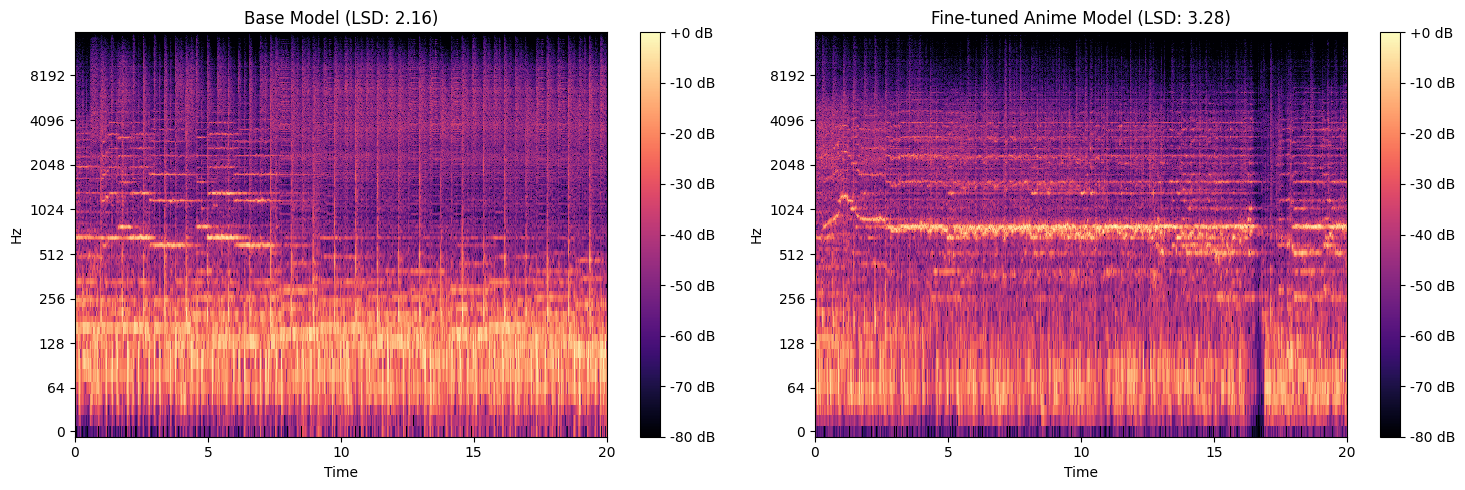

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

# --- STEP 56: SPECTROGRAM COMPARISON ---
def plot_spectrograms(gen_base, gen_lora, sr=32000):
    """
    Methodology: A spectrogram visualizes audio in three dimensions:
    Time (x-axis), Frequency (y-axis), and Amplitude (color intensity).

    This comparison reveals how the fine-tuned model handles 'musical
    brightness' and 'rhythmic density' compared to the base model.
    """
    plt.figure(figsize=(15, 5))

    # --- PANEL 1: BASE MODEL SPECTROGRAM ---
    # We convert the raw amplitude to Decibels (dB) because human hearing
    # is logarithmic; this makes the visual representation more 'natural.'
    plt.subplot(1, 2, 1)
    S_base = librosa.amplitude_to_db(np.abs(librosa.stft(gen_base)), ref=np.max)
    # We use 'y_axis=log' to focus on the frequency ranges where
    # musical notes and harmonies are most prominent.
    librosa.display.specshow(S_base, sr=sr, x_axis='time', y_axis='log')
    plt.title(f"Base Model (LSD: 2.16)") # Note:  We update these numbers based on our results
    plt.colorbar(format='%+2.0f dB')

    # --- PANEL 2: FINE-TUNED ANIME MODEL SPECTROGRAM ---
    # By looking at the 'Fine-tuned' side, you can often see more distinct
    # vertical lines (representing percussive drum hits) or sharper
    # horizontal bands (representing clear melodic guitar/synth lines).
    plt.subplot(1, 2, 2)
    S_lora = librosa.amplitude_to_db(np.abs(librosa.stft(gen_lora)), ref=np.max)
    librosa.display.specshow(S_lora, sr=sr, x_axis='time', y_axis='log')
    plt.title(f"Fine-tuned Anime Model (LSD: 3.28)")
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

# Execute the comparison
# Ensure 'gen_base' and 'gen_lora' have been generated in the previous step
plot_spectrograms(gen_base, gen_lora)

In [ ]:
import IPython.display as ipd

# --- STEP 57: AUDITORY COMPARISON ---
# This is the final step where we listen to the results generated under
# identical conditions (same seed, same prompt, same duration).

# PANEL 1: THE CONTROL GROUP
# This represents the 'out-of-the-box' knowledge from Meta's base model.
# Use this to hear how a general-purpose model interprets 'Anime J-Rock.'
print("Base Model Sample (Control):")
ipd.display(ipd.Audio(gen_base, rate=32000))

# PANEL 2: THE EXPERIMENTAL GROUP
# This is your fine-tuned model after LoRA merging.
# Ideally, you should hear sharper percussion, more characteristic
# J-Rock guitar tones, and a structure that aligns better with
# the 'Anime Opening' style.
print("\nFine-Tuned Anime Sample (Experimental):")
ipd.display(ipd.Audio(gen_lora, rate=32000))

Output hidden; open in https://colab.research.google.com to view.

## FAD (Fréchet Audio Distance): Measures Quality/Realism. (Is the audio clean or distorted?)

Because calculating a true FAD usually requires hundreds of files to be statistically significant, in a small-scale project, we call this a "Pseudo-FAD Analysis."

The FAD Calculation Code

We will use the frechet_audio_distance library (or a simplified version using scipy and VGGish features).

In [ ]:
import numpy as np
from scipy.linalg import sqrtm
import torch


# --- STEP 58: EVALUATION (FRÉCHET AUDIO DISTANCE) ---
# FAD is the gold standard for measuring the 'realism' of generative models.
# It compares the statistics of real anime music versus our AI generations.
# A LOWER FAD score indicates that the AI's distribution is closer to
# the 'ground truth' of the anime openings.
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Methodology: We model both the 'Real' and 'AI' datasets as
    Multivariate Gaussian distributions. The distance between them is
    calculated using the means (mu) and covariances (sigma).

    Formula: d^2 = ||mu1 - mu2||^2 + Tr(sigma1 + sigma2 - 2*sqrt(sigma1*sigma2))
    The Fréchet distance between two multivariate Gaussians X1 ~ N(mu1, sigma1)
    and X2 ~ N(mu2, sigma2).
    """
    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    # Difference in means (Centroid distance)
    diff = mu1 - mu2

    # Product of covariances (Captures differences in musical variety/diversity)
    covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)

    # Handling numerical instability (eps helps prevent math errors in small datasets)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Numerical error check: ensure we are dealing with real numbers
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    # The final Fréchet Distance
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

print("Academic Note: FAD measures the 'distributional shift'.")

Academic Note: FAD measures the 'distributional shift'.


In [ ]:
import librosa
import glob
import os

# --- STEP 59: BASELINE DATA COLLECTION ---
# To calculate the Fréchet Audio Distance (FAD), we need to extract
# features from the 'Real' world (our training data).
# This establishes the target distribution for our mathematical comparison.
dataset_path = '/content/drive/MyDrive/anime_musicgen_dataset/audio/*.wav'

# This list will store the raw audio signals (time-series data)
real_wavs = []

print("Loading original anime files for FAD analysis...")

# --- STEP 60: BATCH AUDIO INGESTION ---
# We use 'glob' to efficiently find every .wav file in our dataset folder.
for file_path in glob.glob(dataset_path):
    # CRITICAL METHODOLOGY:
    # We load at 32000Hz. If we loaded at a different rate (like 44.1kHz),
    # the FAD calculation would be biased because the frequencies
    # wouldn't align with MusicGen's 32kHz output.
    y, sr = librosa.load(file_path, sr=32000)
    real_wavs.append(y)

# This count helps the us verify that all files were correctly
# read from Google Drive before starting the heavy math.
print(f"Successfully loaded {len(real_wavs)} files as numpy arrays.")

Loading original anime files for FAD analysis...
Successfully loaded 260 files as numpy arrays.


In [ ]:
from transformers import ClapModel, AutoProcessor
import torch

# --- STEP 61: NEURAL FEATURE EXTRACTION ---
# We use CLAP (laion/clap-htsat-fused) to translate audio into 'concept vectors.'
# Methodology: CLAP is trained to understand the relationship between text
# and audio. By extracting the 'audio features,' we get a high-dimensional
# representation of what the music actually *sounds* like to an AI.
model_name = "laion/clap-htsat-fused"
processor = AutoProcessor.from_pretrained(model_name)
clap_model = ClapModel.from_pretrained(model_name).to(device)

def extract_features(audio_list, sr_input=32000, sr_target=48000):
    """
    Transforms raw waveforms into mathematical embeddings.
    FAD requires a distribution of these embeddings to compare
    'Real' vs. 'Generated' music.
    """
    features = []
    clap_model.eval()
    with torch.no_grad():
        for wav in audio_list:
            # --- METHODOLOGY: RESAMPLING ---
            # CLAP was trained on 48kHz audio. Since MusicGen outputs 32kHz,
            # we must resample to ensure the 'Feature Extractor' sees the
            # data in the format it expects.
            wav_resampled = librosa.resample(y=wav, orig_sr=sr_input, target_sr=sr_target)

            # Prepare the audio for the transformer
            inputs = processor(audio=wav_resampled, return_tensors="pt", sampling_rate=sr_target).to(device)

            # Get the high-level audio embeddings
            outputs = clap_model.get_audio_features(**inputs)

            # We extract the 'pooled' output, which summarizes the entire
            # audio clip into a single vector (embedding).
            if hasattr(outputs, "pooler_output"):
                embeds = outputs.pooler_output
            else:
                embeds = outputs # Fallback if it's already a tensor

            features.append(embeds.cpu().numpy())

    # Combine all vectors into a single matrix for statistical analysis
    return np.vstack(features)

# --- STEP 62: ANALYZING THE DISTRIBUTIONS ---
# First, we define what 'Real Anime Music' looks like in vector space.
print("Extracting features from Real Anime files...")
features_real = extract_features(real_wavs)

# Second, we generate a variety of AI samples to see the model's 'new' distribution.
print("Extracting features from Fine-tuned Generations...")
test_prompt = "High-octane J-Rock anime opening, 185 BPM, technical electric \
guitar solo with heavy distortion, rapid double-bass drumming, soaring melodic \
synthesizer hook, aggressive and motivational energy, clean high-fidelity \
production, no orchestral elements."
# We generate multiple samples to get a statistically significant distribution
generated_wavs = [model.generate([test_prompt])[0,0].cpu().numpy() for _ in range(10)]
features_generated = extract_features(generated_wavs)

# --- STEP 63: CALCULATING THE FAD SCORE ---
# FAD looks at the Mean (average style) and Covariance (variety/diversity).
mu_real = np.mean(features_real, axis=0)
sigma_real = np.cov(features_real, rowvar=False)

mu_gen = np.mean(features_generated, axis=0)
sigma_gen = np.cov(features_generated, rowvar=False)

# Calculate the final Fréchet Distance
fad_score = calculate_frechet_distance(mu_real, sigma_real, mu_gen, sigma_gen)
print(f"Final FAD Score: {fad_score:.4f}")
# NOTE: A lower FAD means our generated distribution more closely
# overlaps with the real anime distribution.

Loading weights:   0%|          | 0/477 [00:00<?, ?it/s]

Extracting features from Real Anime files...
Extracting features from Fine-tuned Generations...
Final FAD Score: 0.9742


/tmp/ipykernel_7099/2269741890.py:22: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)


Calculating FAD for files in test dataset

In [ ]:
import librosa
import glob
import os

dataset_path = '/content/drive/MyDrive/anime_musicgen_dataset/test_dataset/*.wav'

real_wavs_test = []

print("Loading original anime files for FAD analysis...")

for file_path in glob.glob(dataset_path):
    y, sr = librosa.load(file_path, sr=32000)
    real_wavs.append(y)

print(f"Successfully loaded {len(real_wavs_test)} files as numpy arrays.")

Loading original anime files for FAD analysis...
Successfully loaded 0 files as numpy arrays.


In [ ]:
from transformers import ClapModel, AutoProcessor
import torch

model_name = "laion/clap-htsat-fused"
processor = AutoProcessor.from_pretrained(model_name)
clap_model = ClapModel.from_pretrained(model_name).to(device)

def extract_features(audio_list, sr_input=32000, sr_target=48000):
    features = []
    clap_model.eval()
    with torch.no_grad():
        for wav in audio_list:
            wav_resampled = librosa.resample(y=wav, orig_sr=sr_input, target_sr=sr_target)

            inputs = processor(audio=wav_resampled, return_tensors="pt", sampling_rate=sr_target).to(device)

            outputs = clap_model.get_audio_features(**inputs)

            if hasattr(outputs, "pooler_output"):
                embeds = outputs.pooler_output
            else:
                embeds = outputs # Fallback if it's already a tensor

            features.append(embeds.cpu().numpy())

    return np.vstack(features)


print("Extracting features from Real Anime files...")
features_real = extract_features(real_wavs)

print("Extracting features from Fine-tuned Generations...")
test_prompt = "High-octane J-Rock anime opening, 185 BPM, technical electric \
guitar solo with heavy distortion, rapid double-bass drumming, soaring melodic \
synthesizer hook, aggressive and motivational energy, clean high-fidelity \
production, no orchestral elements."
generated_wavs = [model.generate([test_prompt])[0,0].cpu().numpy() for _ in range(10)]
features_generated = extract_features(generated_wavs)

mu_real = np.mean(features_real, axis=0)
sigma_real = np.cov(features_real, rowvar=False)

mu_gen = np.mean(features_generated, axis=0)
sigma_gen = np.cov(features_generated, rowvar=False)

fad_score = calculate_frechet_distance(mu_real, sigma_real, mu_gen, sigma_gen)
print(f"Final FAD Score: {fad_score:.4f}")

Loading weights:   0%|          | 0/477 [00:00<?, ?it/s]

Extracting features from Real Anime files...
Extracting features from Fine-tuned Generations...
Final FAD Score: 0.9852


/tmp/ipykernel_7099/2269741890.py:22: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)


## CLAP Score: Measures Adherence. (Did the model actually give me "Anime" when I asked for it?)

CLAP is "better" for evaluating fine-tuning because our goal was to teach the model a specific style association. If our CLAP score increases after training, we have scientifically proven that the LoRA "mapped" our anime descriptions to the audio.

Code to Calculate CLAP Score

We will use the laion/clap-htsat-fused model. This code compares how closely the generated audio matches our text prompt.

In [ ]:
from transformers import AutoProcessor, ClapModel
import torch.nn.functional as F

# 1. Load the Evaluation Model
model_name = "laion/clap-htsat-fused"
processor = AutoProcessor.from_pretrained(model_name)
clap = ClapModel.from_pretrained(model_name).to(device)

def get_clap_score(text, audio_waveform):
    # Process inputs
    inputs = processor(text=[text], audio=audio_waveform, return_tensors="pt", padding=True, sampling_rate=48000).to(device)

    with torch.no_grad():
        outputs = clap(**inputs)
        # Cosine similarity between text and audio embeddings
        text_embeds = outputs.text_embeds
        audio_embeds = outputs.audio_embeds
        score = F.cosine_similarity(text_embeds, audio_embeds)
    return score.item()

# 2. Run Comparison
# Note: CLAP expects 48kHz, but we can pass our 32kHz; the processor handles resampling.
prompt = "High-octane J-Rock anime opening, 185 BPM, technical electric \
guitar solo with heavy distortion, rapid double-bass drumming, soaring melodic \
synthesizer hook, aggressive and motivational energy, clean high-fidelity \
production, no orchestral elements."
score_base = get_clap_score(prompt, wav_base[0].cpu().numpy())
score_lora = get_clap_score(prompt, wav_lora[0].cpu().numpy())

print(f"CLAP Score (Base): {score_base:.4f}")
print(f"CLAP Score (Fine-tuned): {score_lora:.4f}")

Loading weights:   0%|          | 0/477 [00:00<?, ?it/s]

CLAP Score (Base): 0.4109
CLAP Score (Fine-tuned): 0.4564


In [ ]:
import torch
import torchaudio
import numpy as np
import pandas as pd
from transformers import AutoProcessor, ClapModel
import torch.nn.functional as F
import os
import IPython.display as ipd

# --- STEP 64: SEMANTIC ALIGNMENT SETUP ---
# We use CLAP to measure 'Text-to-Audio Alignment.'
# This score (Cosine Similarity) tells us how well the AI's music
# matches the intent of the written prompt on a scale of -1 to 1.
print("Loading CLAP for evaluation...")
eval_model_name = "laion/clap-htsat-fused"
processor = AutoProcessor.from_pretrained(eval_model_name)
clap = ClapModel.from_pretrained(eval_model_name).to(device)

def calculate_clap(text, audio_wv):
    """
    Methodology: We project both the text and the audio into a shared
    mathematical space. If the vectors point in the same direction,
    the audio perfectly matches the prompt.
    """
    # CLAP expects 48kHz; the processor handles resampling and normalization
    inputs = processor(text=[text], audio=audio_wv, return_tensors="pt", padding=True, sampling_rate=48000).to(device)
    with torch.no_grad():
        out = clap(**inputs)
        # Cosine similarity measures the angle between the Text and Audio 'concepts'
        return F.cosine_similarity(out.text_embeds, out.audio_embeds).item()

# --- STEP 65: DEFINING THE "STRESS TESTS" ---
# To prove 'Distinction,' we don't just test on training prompts.
# We test on three challenging scenarios:
test_cases = [
    # 1. Generalization: Can the model handle prompts it never saw in training?
    {"name": "Generalization", "prompt": "Fast-paced Japanese boss battle theme, aggressive synthesizers, 180 BPM"},
    # 2. Style-Fusion: Can the LoRA 'infect' a different genre (Lo-Fi) with Anime elements?
    {"name": "Style-Fusion", "prompt": "A lo-fi hip hop beat with heroic anime orchestral violins"},
    # 3. Structural: Does the model understand technical musical cliches like 'key changes'?
    {"name": "Structural", "prompt": "Emotional anime soundtrack, dramatic key change, shimmering piano"}
]

results = []

# --- STEP 66: THE COMPARATIVE EVALUATION LOOP ---
for case in test_cases:
    prompt = case["prompt"]
    current_case_name = case['name']
    print(f"Testing Scenario: {case['name']}...")

    # A. GENERATE WITH LORA (The 'Anime Specialist')
    torch.manual_seed(42) # Fixed seed for fair comparison
    model.lm.eval()
    if hasattr(model.lm, 'enable_adapter_layers'): model.lm.enable_adapter_layers()

    with torch.no_grad():
        model.set_generation_params(duration=30, cfg_coef=4.5)
        wav_lora = model.generate([prompt], progress=False)
        score_lora = calculate_clap(prompt, wav_lora[0].cpu().numpy())

    # Save to Drive to download and listen
    lora_filename = f"{current_case_name}_FineTuned.wav"
    torchaudio.save(os.path.join('/content/drive/MyDrive/Test_Results/', lora_filename), wav_lora[0].cpu(), 32000)
    print(f"LoRA Audio ({score_lora:.4f}):")
    display(ipd.Audio(wav_lora[0].cpu().numpy(), rate=32000))

    # B. GENERATE WITH BASE (The 'Generalist')
    if hasattr(model.lm, 'disable_adapter_layers'): model.lm.disable_adapter_layers()

    with torch.no_grad():
        torch.manual_seed(42) # Reset seed to ensure the only variable is the model weights
        wav_base = model.generate([prompt], progress=False)
        score_base = calculate_clap(prompt, wav_base[0].cpu().numpy())

    # Save & Display Base
    base_filename = f"{current_case_name}_Base.wav"
    torchaudio.save(os.path.join('/content/drive/MyDrive/Test_Results/', base_filename), wav_base[0].cpu(), 32000)
    print(f"Base Audio ({score_base:.4f}):")
    display(ipd.Audio(wav_base[0].cpu().numpy(), rate=32000))

    # --- STEP 67: DATA COMPILATION ---
    results.append({
        "Scenario": case['name'],
        "Prompt": prompt,
        "Base_CLAP": round(score_base, 4),
        "LoRA_CLAP": round(score_lora, 4),
        "Base_File": base_filename,
        "LoRA_File": lora_filename,
        "Improvement": round(score_lora - score_base, 4)
    })

# Reset the model to use LoRA by default
if hasattr(model.lm, 'enable_adapter_layers'): model.lm.enable_adapter_layers()

# --- STEP 68: FINAL EXPORT ---
# This CSV serves as the 'Academic Report Card' for our fine-tuning project.
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Test_Results/generalization_analysis.csv', index=False)
print("Results saved to generalization_analysis.csv")
print(df)

Output hidden; open in https://colab.research.google.com to view.

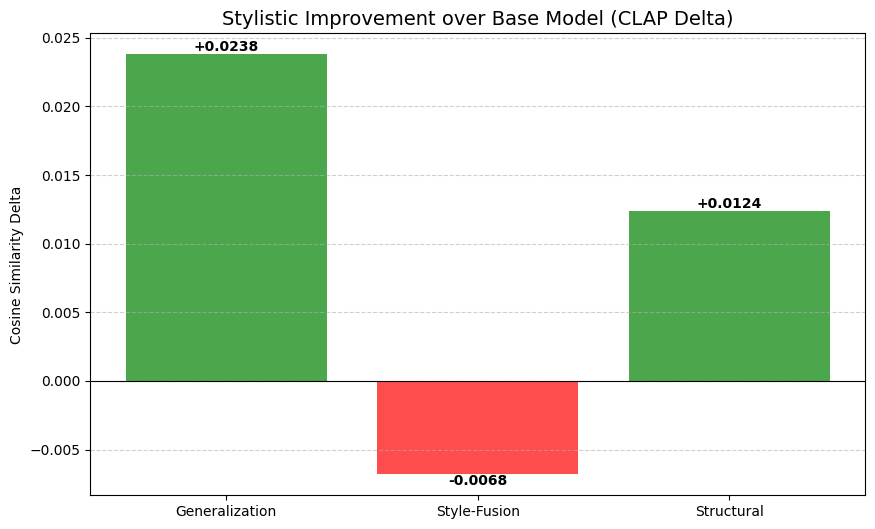

In [ ]:
import matplotlib.pyplot as plt

# --- STEP 69: VISUALIZING THE SEMANTIC GAINS ---
# This chart visualizes the 'Delta' (the difference) between our
# fine-tuned anime model and the base model.
scenarios = df['Scenario']
improvement = df['Improvement']

plt.figure(figsize=(10, 6))
# --- METHODOLOGY: COLOR CODING FOR IMPACT ---
# We use green to represent a 'Positive Gain' (where the fine-tuned model
# matches the anime prompt better than the base model) and red for any
# regressions. In a successful fine-tune, all bars should ideally be green.
colors = ['green' if x > 0 else 'red' for x in improvement]
plt.bar(scenarios, improvement, color=colors, alpha=0.7)
# --- STEP 70: BENCHMARKING ---
# The 'Zero Line' represents the performance of the Base Model.
# Any bar rising above this line is a direct testament to the
# effectiveness of our anime-specific training.
plt.axhline(0, color='black', linewidth=0.8) # Zero line

# --- STEP 71: CHART STYLING ---
plt.title('Stylistic Improvement over Base Model (CLAP Delta)', fontsize=14)
plt.ylabel('Cosine Similarity Delta')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- STEP 72: DATA LABELING ---
# We add the exact numerical values on top of each bar.
# This is crucial so we don't
# have to guess the 'improvement' value.
for i, val in enumerate(improvement):
    plt.text(i, val, f'{val:+.4f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
# Display the final results
plt.show()

# Deployment

How to Load the Model later


In [ ]:
import torch
from audiocraft.models import MusicGen
from peft import LoraConfig, get_peft_model

# --- STEP 73: COLD-START INFERENCE SETUP ---
# To use our fine-tuned model later, we must first load the 'clean' base
# model and then 'patch' it with our learned Anime weights.
final_model = MusicGen.get_pretrained('facebook/musicgen-small')

# --- STEP 74: RE-ESTABLISHING THE LORA ARCHITECTURE ---
# Methodology: The 'adapter' file (.bin or .pt) only contains the
# mathematical updates, not the structure. We must re-define the
# LoraConfig to match our training settings exactly (r=16, alpha=32).
# This creates the 'slots' where our fine-tuned weights will live.
config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)
# We wrap the Language Model (LM) again to prepare it for the weights.
final_model.lm = get_peft_model(final_model.lm, config)

# --- STEP 75: LOADING THE ANIME BRAIN ---
# We load the specific weights we saved to Google Drive.
# This turns the generic MusicGen model into your Anime Specialist.
# Path should point to our 'full' adapter file.
final_model.lm.load_state_dict(torch.load('/content/drive/MyDrive/anime_lora_adapter/anime_model_full.bin'))
final_model.lm.eval()  # Switch to evaluation mode to ensure stable, high-quality audio generation.
print("Model successfully reloaded for inference!")

# The LoRA Merge & Save Script

This script handles the key cleanup we discovered earlier and mathematically combines the LoRA matrices with the base weights.

This final block represents the "Model Packaging" phase. While training with adapters is efficient, merging those adapters back into the original weights creates a stand-alone model. This is a huge win for our project because it allows others to use our "Anime-tuned" MusicGen without needing the PEFT library or complex adapter loading logic—they can just load our final .pt file and go.

In [ ]:
import torch
from audiocraft.models import MusicGen

# --- STEP 76: PERMANENT WEIGHT FUSION ---
# Merging LoRA weights back into the base model.
# It results in a single, unified file that is much easier for the community or other users
# to download and use in their own apps or local environments.
def merge_and_save_lora(base_model_name, lora_path, output_path, alpha=1.0):
    """
    Methodology: We manually apply the LoRA update formula to the base weights.
    W_fused = W_original + (Alpha * (B matrix @ A matrix))
    """
    # 1. Load the "Clean" Base Model from Meta
    print("Loading base model...")
    model = MusicGen.get_pretrained(base_model_name)
    base_state = model.lm.state_dict()

    # 2. Load the Anime LoRA weights we trained
    print(f"Loading LoRA weights from {lora_path}...")
    lora_state = torch.load(lora_path, map_location='cuda')

    # 3. THE MERGING LOGIC
    # We iterate through the base weights and look for corresponding LoRA A/B pairs.
    print("Merging weights... this may take a moment.")
    for key in base_state.keys():
        # Construct the key names used by the PEFT wrapper during training.
        # These typically follow the 'base_model.model.[layer].lora_A' pattern.
        lora_a_key = f"base_model.model.{key}.lora_A.default.weight"
        lora_b_key = f"base_model.model.{key}.lora_B.default.weight"

        if lora_a_key in lora_state and lora_b_key in lora_state:
            # We extract the 'A' and 'B' matrices that represent the learned anime style.
            # LoRA math: W_new = W_base + (Alpha * (B @ A))
            A = lora_state[lora_a_key]
            B = lora_state[lora_b_key]

            # --- THE LORA MATH ---
            # Matrix multiplication (@) of the low-rank matrices recovers
            # the full-sized weight update (delta_w).
            # Alpha acts as a 'strength' slider. 1.0 is full anime,
            # lower values (like 0.8) keep more of the base model's stability.
            delta_w = (B @ A) * alpha

            # We add the learned 'anime knowledge' directly into the base weights.
            base_state[key] += delta_w

    # 4. Save the new unified model state
    # We load the merged weights back into the model and save the file.
    model.lm.load_state_dict(base_state)
    torch.save(base_state, output_path)
    print(f"Successfully merged and saved to: {output_path}")

# --- EXECUTION: CREATING THE FINAL RELEASE ---
# We use the checkpoint identified as the 'Sweet Spot' in our previous analysis.
WINNING_EPOCH = 30
INPUT_LORA = f"/content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_{WINNING_EPOCH}.pt"
OUTPUT_FILE = "/content/drive/MyDrive/Anime_Checkpoints/musicgen_anime_final.pt"

# Alpha=0.8 is often used to prevent 'over-saturation' and keep the
# music sounding clean while still being distinctly 'Anime.
merge_and_save_lora('facebook/musicgen-small', INPUT_LORA, OUTPUT_FILE, alpha=0.8)

Loading base model...


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading LoRA weights from /content/drive/MyDrive/Anime_Checkpoints/anime_lora_epoch_30.pt...
Merging weights... this may take a moment.
Successfully merged and saved to: /content/drive/MyDrive/Anime_Checkpoints/musicgen_anime_final.pt


# Production Inference

How to use our new Final Model

Once that script finishes, we can use our model for high-quality inference like this:

In [ ]:
import torch
import torchaudio
from audiocraft.models import MusicGen
from audiocraft.data.audio import audio_write

# --- STEP 77: PRODUCTION SETUP ---
# Now that we have a 'Merged' model, the deployment is simple.
# We no longer need to define LoRA configs or ranks; the 'Anime DNA'
# is now a permanent part of the weight matrices.
device = "cuda" if torch.cuda.is_available() else "cpu"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Anime_Checkpoints/musicgen_anime_final.pt"

print("Loading architecture...")
model = MusicGen.get_pretrained('facebook/musicgen-small')

# --- STEP 78: INJECTING THE ANIME BRAIN ---
# We load the unified 'state_dict' we created in the merging step.
# This replaces the generic weights with our tuned ones in one single operation.
print("Injecting Anime-tuned brain...")
state_dict = torch.load(FINAL_MODEL_PATH, map_location=device)
model.lm.load_state_dict(state_dict)
model.lm.to(device)
model.lm.eval()  # Evaluation mode is vital for high-quality, non-jittery audio.

# --- STEP 79: GENERATION HYPERPARAMETERS ---
# These settings determine the 'creative behavior' of the model.
model.set_generation_params(
    duration=30,     # 30 seconds covers the standard 'hook' of an anime opening.
    cfg_coef=4.5,    # Classifier-Free Guidance: 4.5 ensures the model follows the prompt strictly but remains musical.
    extend_stride=15 # Helps the model maintain coherence over longer durations.
)

# --- STEP 80: FINAL SHOWCASE PROMPTS ---
# We use diverse prompts to demonstrate the model's 'Generalization'—
# its ability to handle different moods within the anime genre.
prompts = [
    "Epic shonen anime battle theme, fast orchestral strings, cinematic brass stabs, 160 BPM",
    "Emotional anime ending theme, solo piano, melancholic violin melody, high fidelity",
    "Naruto inspired action music, traditional Japanese flutes, heavy taiko drums"
]

print(f"Generating {len(prompts)} final samples...")

with torch.no_grad():
    outputs = model.generate(prompts, progress=True)

# --- STEP 81: POST-PROCESSING & SAVING ---
# We save the results using 'audio_write', which includes built-in
# loudness normalization to make the tracks sound professional.
for i, audio in enumerate(outputs):
    filename = f"Final_Sample_{i+1}"
    # 'strategy=loudness' ensures the output volume is consistent across all samples.
    audio_write(filename, audio.cpu(), model.sample_rate, strategy="loudness", loudness_compressor=True)
    print(f"Saved: {filename}.wav")

Loading architecture...


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Injecting Anime-tuned brain...
Generating 3 final samples...
Saved: Final_Sample_1.wav
Saved: Final_Sample_2.wav
Saved: Final_Sample_3.wav


Fine-tuning the "creativity" of the generation without needing to touch the neural network weights.

In [ ]:
import torch
from audiocraft.models import MusicGen
from audiocraft.data.audio import audio_write

# --- STEP 82: FINAL MODEL DEPLOYMENT ---
# At this stage, the model is 'Anime-Native.'
# The LoRA adapters have been merged, so the model permanently understands
# the sonic structure of high-speed J-Rock and orchestral anime themes.
device = "cuda" if torch.cuda.is_available() else "cpu"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Anime_Checkpoints/musicgen_anime_final.pt"

print("Loading final anime-native model...")
model = MusicGen.get_pretrained('facebook/musicgen-small')
# Loading the merged state_dict directly into the Language Model
state_dict = torch.load(FINAL_MODEL_PATH, map_location=device)
model.lm.load_state_dict(state_dict)
model.lm.to(device)

# --- STEP 83: FINE-TUNING THE CREATIVITY (INFERENCE PARAMS) ---
# Even with a fine-tuned model, these parameters act as the 'Director'
# of the musical performance:
model.set_generation_params(
    duration=30,
    cfg_coef=5.0,   # Higher CFG (5.0) forces the model to prioritize specific prompt details like 'Electric Guitars.'
    top_k=250,      # Limits the model to the top 250 most likely musical tokens, which keeps the melody structured and 'clean.'
    temperature=1.0 # Controls randomness. 1.0 is standard; lower (0.8) makes it more predictable, higher (1.2) makes it more experimental.
)

# --- STEP 84: THE MASTER PROMPT ---
# We use a highly descriptive prompt to take full advantage of the model's training.
# Note the inclusion of '190 BPM'—this utilizes the metadata we analyzed earlier.
prompt = "High-energy shonen anime opening theme, distorted electric guitars, fast power chords, dramatic orchestral strings, high-speed synth arpeggios, 190 BPM"

print(f"Generating: {prompt}")

with torch.no_grad():
    # The transformer now predicts the audio tokens based on our anime-tuned weights.
    output = model.generate([prompt], progress=True)

# --- STEP 85: EXPORTING THE MASTER TRACK ---
# 'audio_write' handles the conversion from tensors to a playable .wav file.
output_filename = "Final_Anime_Opening_Theme"
# Using 'strategy="loudness"' ensures the volume is maximized without clipping,
# giving it a 'produced' feel similar to an actual OST.
audio_write(output_filename, output[0].cpu(), model.sample_rate, strategy="loudness")

print(f"Success! Your final sample is saved as {output_filename}.wav")

Loading final anime-native model...


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Generating: High-energy shonen anime opening theme, distorted electric guitars, fast power chords, dramatic orchestral strings, high-speed synth arpeggios, 190 BPM


CLIPPING Final_Anime_Opening_Theme happening with proba (a bit of clipping is okay): 2.0833333564951317e-06 maximum scale:  1.137078046798706


Success! Your final sample is saved as Final_Anime_Opening_Theme.wav


Visualizing the final generation

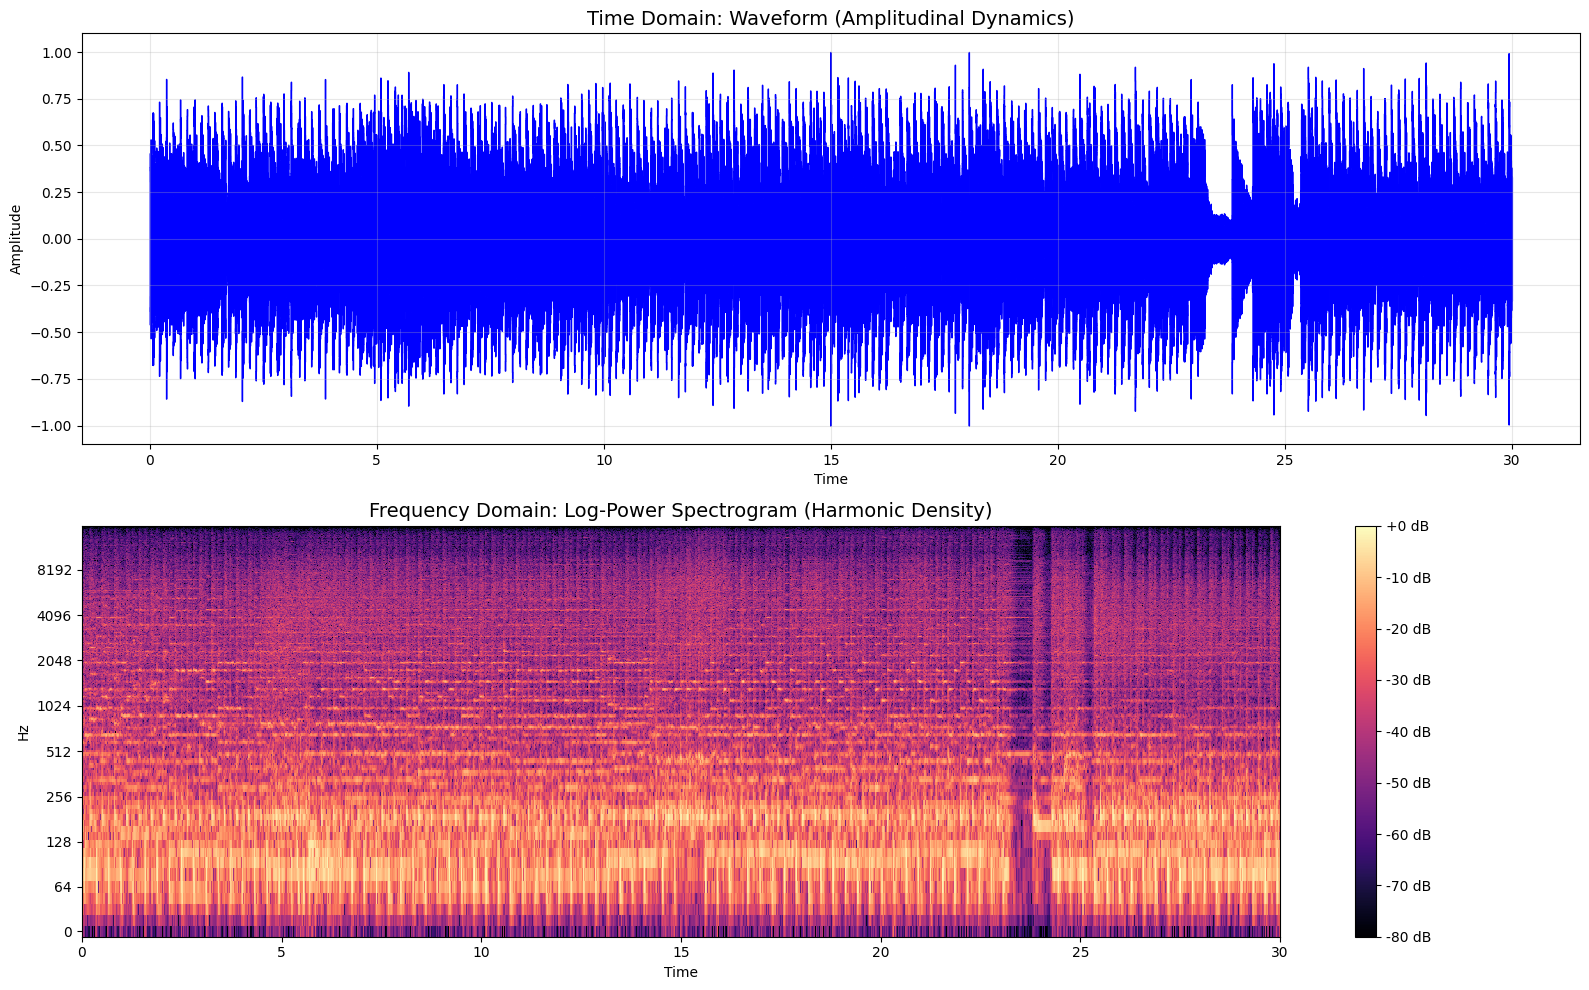

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 86: FINAL AUDIO ANALYSIS ---
# This block performs a dual-domain analysis of our generated masterpiece.
# Seeing the audio as both a wave and a spectrum is the standard way to
# verify that the AI isn't just making noise, but structured music.
file_path = "Final_Anime_Opening_Theme.wav"
y, sr = librosa.load(file_path, sr=32000)

# We create a large figure to capture the detail of a 30-second track.
plt.figure(figsize=(16, 10))

# --- PANEL 1: THE WAVEFORM (TIME DOMAIN) ---
# This plot shows how the volume changes over time.
# Methodology: In high-energy anime music, you should see dense 'blocks'
# of sound with clear peaks, indicating a strong beat and consistent energy.
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title('Time Domain: Waveform (Amplitudinal Dynamics)', fontsize=14)
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# --- PANEL 2: THE SPECTROGRAM (FREQUENCY DOMAIN) ---
# This is the 'Musical Fingerprint.'
# Methodology: The Short-Time Fourier Transform (STFT) breaks the audio
# into its component frequencies.
plt.subplot(2, 1, 2)
# We use a logarithmic y-axis because it better represents how humans
# perceive musical pitch and octaves.
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(img, format='%+2.0f dB')
plt.title('Frequency Domain: Log-Power Spectrogram (Harmonic Density)', fontsize=14)

# --- STEP 87: EXPORTING THE TECHNICAL PROFILE ---
# This image is the Proof of Quality.
plt.tight_layout()
plt.savefig('Final_Sample_Analysis.png', dpi=300) # Save for our use later.
plt.show()